# Poems Generation

In [2]:
# Reading the text file into a string
with open('poems.txt', 'r') as file:
	text = file.read()

# A preview of the text file
print(text)

ï»¿Buffalo Billâ€™s
defunct
who used to
ride a watersmooth-silver
stallion
and break one two three four five pigeons just like that
Jesus

he was a handsome man
and what i want to know is
how do you like your blueeyed boy
Mister Death

Had I the heavenâ€™s embroidered cloths,
Enwrought with golden and silver light,
The blue and the dim and the dark cloths
Of night and light and the half-light,
I would spread the cloths under your feet:
But I, being poor, have only my dreams;
I have spread my dreams under your feet;
Tread softly because you tread on my dreams.

He clasps the crag with crooked hands;
Close to the sun in lonely lands,
Ringâ€™d with the azure world, he stands.

The wrinkled sea beneath him crawls;
He watches from his mountain walls,
And like a thunderbolt he falls.

Some say the world will end in fire,
Some say in ice.
From what Iâ€™ve tasted of desire
I hold with those who favor fire.
But if it had to perish twice,
I think I know enough of hate
To say that for destruction

In [3]:
# Storing all the unique characters present in the text
vocabulary = sorted(list(set(text)))

In [4]:
vocabulary[:20]

['\n',
 ' ',
 '!',
 ',',
 '-',
 '.',
 ':',
 ';',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'H',
 'I',
 'J',
 'M',
 'O',
 'R']

In [5]:
# Creating dictionaries to map each character to an index
char_to_indices = dict((c, i) for i, c in enumerate(vocabulary))
print(char_to_indices)

{'\n': 0, ' ': 1, '!': 2, ',': 3, '-': 4, '.': 5, ':': 6, ';': 7, 'A': 8, 'B': 9, 'C': 10, 'D': 11, 'E': 12, 'F': 13, 'H': 14, 'I': 15, 'J': 16, 'M': 17, 'O': 18, 'R': 19, 'S': 20, 'T': 21, 'Y': 22, 'a': 23, 'b': 24, 'c': 25, 'd': 26, 'e': 27, 'f': 28, 'g': 29, 'h': 30, 'i': 31, 'j': 32, 'k': 33, 'l': 34, 'm': 35, 'n': 36, 'o': 37, 'p': 38, 'q': 39, 'r': 40, 's': 41, 't': 42, 'u': 43, 'v': 44, 'w': 45, 'y': 46, 'z': 47, '»': 48, '¿': 49, 'â': 50, 'ï': 51, '”': 52, '€': 53, '™': 54}


In [6]:
indices_to_char = dict((i, c) for i, c in enumerate(vocabulary))

print(indices_to_char)

{0: '\n', 1: ' ', 2: '!', 3: ',', 4: '-', 5: '.', 6: ':', 7: ';', 8: 'A', 9: 'B', 10: 'C', 11: 'D', 12: 'E', 13: 'F', 14: 'H', 15: 'I', 16: 'J', 17: 'M', 18: 'O', 19: 'R', 20: 'S', 21: 'T', 22: 'Y', 23: 'a', 24: 'b', 25: 'c', 26: 'd', 27: 'e', 28: 'f', 29: 'g', 30: 'h', 31: 'i', 32: 'j', 33: 'k', 34: 'l', 35: 'm', 36: 'n', 37: 'o', 38: 'p', 39: 'q', 40: 'r', 41: 's', 42: 't', 43: 'u', 44: 'v', 45: 'w', 46: 'y', 47: 'z', 48: '»', 49: '¿', 50: 'â', 51: 'ï', 52: '”', 53: '€', 54: '™'}


In [7]:
len(text)

1770

In [9]:
# Dividing the text into subsequences of length max_length
# So that at each time step the next max_length characters
# are fed into the network
max_length = 100
steps = 5
sentences = []
next_chars = []
for i in range(0, len(text) - max_length, steps):
  sentences.append(text[i: i + max_length])
  next_chars.append(text[i + max_length])

In [10]:
sentences[1]
#next_chars[1]

'ffalo Billâ€™s\ndefunct\nwho used to\nride a watersmooth-silver\nstallion\nand break one two three four f'

In [11]:
sentences[0]
#next_chars[0]

'ï»¿Buffalo Billâ€™s\ndefunct\nwho used to\nride a watersmooth-silver\nstallion\nand break one two three f'

In [12]:
len(sentences)

334

In [13]:
next_chars[0]

'o'

In [14]:
# Hot encoding each character into a boolean vector
import numpy as np
# Initializing a matrix of boolean vectors with each column representing
# the hot encoded representation of the character
X = np.zeros((len(sentences), max_length, len(vocabulary)), dtype = bool)
y = np.zeros((len(sentences), len(vocabulary)), dtype = bool)

# Placing the value 1 at the appropriate position for each vector
# to complete the hot-encoding process
for i, sentence in enumerate(sentences):
	for t, char in enumerate(sentence):
		X[i, t, char_to_indices[char]] = 1
	y[i, char_to_indices[next_chars[i]]] = 1


In [15]:
sentences[0]

'ï»¿Buffalo Billâ€™s\ndefunct\nwho used to\nride a watersmooth-silver\nstallion\nand break one two three f'

In [16]:
y[0]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [17]:
X.shape

(334, 100, 55)

In [18]:
X[0, 2, :]


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False])

In [19]:
len(vocabulary)

55

In [22]:
from tensorflow.keras.layers import GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import RMSprop

# Initializing the LSTM network
model = Sequential()

# Defining the cell type
model.add(GRU(128, input_shape =(max_length, len(vocabulary))))

# Defining the densely connected Neural Network layer
model.add(Dense(len(vocabulary)))

# Defining the activation function for the cell
model.add(Activation('softmax'))

# Defining the optimizing function
optimizer = RMSprop()

# Configuring the model for training
model.compile(loss ='categorical_crossentropy', optimizer = optimizer)
model.summary()

C:\Users\lulul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 128)                 │          71,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 55)                  │           7,095 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 55)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,135 (305.21 KB)

 Trainable params: 78,135 (305.21 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Training the GRU model
model.fit(X, y, batch_size = 128, epochs = 80)#, callbacks = callbacks)


Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - loss: 3.9818
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - loss: 3.9038
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - loss: 3.7726
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - loss: 3.3078
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 428ms/step - loss: 3.2149
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - loss: 3.0599
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - loss: 3.0220
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step - loss: 3.0045
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 426ms/step - loss: 2.9915
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - loss: 2.9779
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - loss: 2.9734
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 428ms/step - loss: 2.9580
Epoch 13/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - loss: 2.9472
Epoch 14/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - loss: 2.9499
Epoch 15/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - loss: 2.9710
Epoch 16/80
3/3 ━━━

In [24]:
print(X.shape)
print(y.shape)

(334, 100, 55)
(334, 55)


In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Attention, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

# 1) Définir l'entrée
inputs = Input(shape=(100, 55))  # (longueur de séquence, dimension de l'entrée)

# 2) Couche GRU renvoyant la séquence complète
#    pour pouvoir appliquer l'attention sur chaque pas de temps
gru_output = GRU(128, return_sequences=True)(inputs)

# 3) Auto-attention : on utilise la même sortie comme query, key et value
attn_output = Attention()([gru_output, gru_output])

# 4) Agrégation du tenseur attn_output (on peut faire sum, mean, max, etc.)
#    On enveloppe l'opération dans une couche Lambda pour rester dans le "modèle fonctionnel"
context_vector = Lambda(lambda x: tf.reduce_mean(x, axis=1))(attn_output)

# 5) Couche de sortie (51 classes)
outputs = Dense(55, activation='softmax')(context_vector)

# 6) Créer le modèle
model = Model(inputs=inputs, outputs=outputs)

# 7) Compiler le modèle
optimizer = RMSprop()
model.compile(loss='categorical_crossentropy', optimizer=optimizer)

# 8) Résumé du modèle
model.summary()

# 9) Entraînement
# X.shape = (332, 100, 51)
# y.shape = (332, 51)
model.fit(X, y, batch_size=128, epochs=30)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 100, 55)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_3 (GRU)                   │ (None, 100, 128)          │          71,040 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_2 (Attention)       │ (None, 100, 128)          │               0 │ gru_3[0][0], gru_3[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_2 (Lambda)             │ (None, 128)               │               0 │ attention_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 55)                │           7,095 │ lambda_2[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 78,135 (305.21 KB)

 Trainable params: 78,135 (305.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step - loss: 3.9877
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 437ms/step - loss: 3.9196
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step - loss: 3.8019
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 444ms/step - loss: 3.3504
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - loss: 3.1518
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - loss: 3.0832
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - loss: 3.0600
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 437ms/step - loss: 3.0500
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - loss: 3.0309
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - loss: 3.0332
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - loss: 3.0300
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - loss: 3.0232
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - loss: 3.0235
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 407ms/step - loss: 3.0159
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - loss: 3.0087
Epoch 16/30
3/3 ━━━

In [28]:
# Helper function to sample an index from a probability array
def sample_index(preds, temperature = 1.0):
# temperature determines the freedom the function has when generating text

	# Converting the predictions vector into a numpy array
	preds = np.asarray(preds).astype('float64')

	# Normalizing the predicitons array
	preds = np.log(preds) / temperature
	exp_preds = np.exp(preds)
	preds = exp_preds / np.sum(exp_preds)

	# The main sampling step. Creates an array of probablities signifying
	# the probability of each character to be the next character in the
	# generated text
	probas = np.random.multinomial(1, preds, 1)

	# Returning the character with maximum probability to be the next character
	# in the generated text
	return np.argmax(probas)


In [29]:
max_length

100

In [30]:
import numpy as np

In [31]:
def generate_text(length, diversity):
	# Get random starting text
	start_index = np.random.randint(0, len(text) - max_length - 1)

	# Defining the generated text
	generated = ''
	sentence = text[start_index: start_index + max_length]
	generated += sentence

	# Generating new text of given length
	for i in range(length):

			# Initializing the predicition vector
			x_pred = np.zeros((1, max_length, len(vocabulary)))
			for t, char in enumerate(sentence):
				x_pred[0, t, char_to_indices[char]] = 1.

			# Making the predicitons
			preds = model.predict(x_pred, verbose = 0)[0]

			# Getting the index of the next most probable index
			next_index = sample_index(preds, diversity)

			# Getting the most probable next character using the mapping built
			next_char = indices_to_char[next_index]

			# Generating new text
			generated += next_char
			sentence = sentence[1:] + next_char
	return generated


In [34]:
print(generate_text(500, 0.2))

a yellow wood,
And sorry I could not travel both
And be one traveler, long I stood
And looked down o   e   e eee   t       e   ae  e  e e  e et et  eyete    e  e    e  e eeeee  ee ee    e    te ee e    e    e  e     e te e ee     t   e ee      ee    ee e       ee        t eet  e     e ee   t  e    eee  ee   etet  e   e   e e   e e    e   e    t    e  eteeee e e  ee a e        eaea   ee   eeeete    eee   oe et    ee      e    e         ee    ta      et t   e    e  tt e ee eee  e     ete eeee e      t     teeee  e     eee  e eee       e       e  ee e e  e       e  e  eet et     e    e e   ee    


# Music Generation

In this portion of the lab, we will explore building a Recurrent Neural Network (RNN) for music generation. We will train a model to learn the patterns in raw sheet music in [ABC notation](https://fr.wikipedia.org/wiki/ABC_(notation)) and then use this model to generate new music.

## Dependencies

First, let's download `util.py` and `song.json`, install dependencies, and import the relevant packages we'll need for this lab.

In [1]:
# Import Tensorflow 2.0
import tensorflow as tf

# Import all remaining packages
import numpy as np
import os
import time
import functools
from IPython import display as ipythondisplay
from tqdm import tqdm
import json


In [2]:
import util

pygame 2.6.1 (SDL 2.28.4, Python 3.10.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Dataset



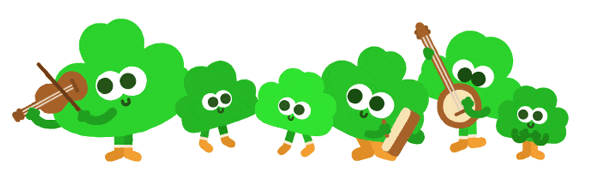

We've gathered a dataset of thousands of Irish folk songs, represented in the ABC notation. Let's download the dataset and inspect it:

In [3]:
# Download the dataset

songs = util.load_songs("songs.json")

# Print one of the songs to inspect it in greater detail!
song  = songs[0]
print("\nExample song: ")
print(song)


Example song: 
X:1
T:Alexander's
Z: id:dc-hornpipe-1
M:C|
L:1/8
K:D Major
(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!
dAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!
AG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!
FAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!


We can easily convert a song in ABC notation to an audio waveform and play it back. Be patient for this conversion to run, it can take some time.


In [4]:
# Convert the ABC notation to audio file and listen to it

#util.play_song(song)



One important thing to think about is that this notation of music does not simply contain information on the notes being played, but additionally there is meta information such as the song title, key, and tempo. How does the number of different characters that are present in the text file impact the complexity of the learning problem? This will become important soon, when we generate a numerical representation for the text data.


In [5]:
# Join our list of song strings into a single string containing all songs
songs_joined = "\n\n".join(songs)

# Find all unique characters in the joined string
vocab = sorted(set(songs_joined))
print("There are", len(vocab), "unique characters in the dataset")

There are 83 unique characters in the dataset


## Process the dataset for the learning task

Let's take a step back and consider our prediction task. We're trying to train a `RNN model` to learn patterns in ABC music, and then use this model to generate (i.e., predict) a new piece of music based on this learned information.

Breaking this down, what we're really asking the model is: given a character, or a sequence of characters, what is the most probable next character? We'll train the model to perform this task.

To achieve this, we will input a sequence of characters to the model, and train the model to predict the output, that is, the following character at each time step. `RNNs` maintain an internal state that depends on previously seen elements, so information about all characters seen up until a given moment will be taken into account in generating the prediction.

**Vectorize the text**

Before we begin training our RNN model, we'll need to create a numerical representation of our text-based dataset. To do this, we'll generate two lookup tables: one that maps characters to numbers, and a second that maps numbers back to characters. Recall that we just identified the unique characters present in the text.


In [6]:
### Define numerical representation of text ###
import numpy as np
# Create a mapping from character to unique index.
# For example, to get the index of the character "d",
#   we can evaluate `char2idx["d"]`.
char2idx = {u:i for i, u in enumerate(vocab)}
print(char2idx)
# Create a mapping from indices to characters. This is
#   the inverse of char2idx and allows us to convert back
#   from unique index to the character in our vocabulary.
idx2char = np.array(vocab)

{'\n': 0, ' ': 1, '!': 2, '"': 3, '#': 4, "'": 5, '(': 6, ')': 7, ',': 8, '-': 9, '.': 10, '/': 11, '0': 12, '1': 13, '2': 14, '3': 15, '4': 16, '5': 17, '6': 18, '7': 19, '8': 20, '9': 21, ':': 22, '<': 23, '=': 24, '>': 25, 'A': 26, 'B': 27, 'C': 28, 'D': 29, 'E': 30, 'F': 31, 'G': 32, 'H': 33, 'I': 34, 'J': 35, 'K': 36, 'L': 37, 'M': 38, 'N': 39, 'O': 40, 'P': 41, 'Q': 42, 'R': 43, 'S': 44, 'T': 45, 'U': 46, 'V': 47, 'W': 48, 'X': 49, 'Y': 50, 'Z': 51, '[': 52, ']': 53, '^': 54, '_': 55, 'a': 56, 'b': 57, 'c': 58, 'd': 59, 'e': 60, 'f': 61, 'g': 62, 'h': 63, 'i': 64, 'j': 65, 'k': 66, 'l': 67, 'm': 68, 'n': 69, 'o': 70, 'p': 71, 'q': 72, 'r': 73, 's': 74, 't': 75, 'u': 76, 'v': 77, 'w': 78, 'x': 79, 'y': 80, 'z': 81, '|': 82}


In [7]:
idx2char

array(['\n', ' ', '!', '"', '#', "'", '(', ')', ',', '-', '.', '/', '0',
       '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '=', '>',
       'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
       '[', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i',
       'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v',
       'w', 'x', 'y', 'z', '|'], dtype='<U1')



This gives us an integer representation for each character. Observe that the unique characters (i.e., our vocabulary) in the text are mapped as indices from 0 to `len(unique)`. Let's take a peek at this numerical representation of our dataset:


In [8]:
print('{')
for char,_ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '"' :   3,
  '#' :   4,
  "'" :   5,
  '(' :   6,
  ')' :   7,
  ',' :   8,
  '-' :   9,
  '.' :  10,
  '/' :  11,
  '0' :  12,
  '1' :  13,
  '2' :  14,
  '3' :  15,
  '4' :  16,
  '5' :  17,
  '6' :  18,
  '7' :  19,
  ...
}


In [9]:
songs_joined

'X:1\nT:Alexander\'s\nZ: id:dc-hornpipe-1\nM:C|\nL:1/8\nK:D Major\n(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!\ndAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!\nAG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!\nFAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!\n\nX:2\nT:An Buachaill Dreoite\nZ: id:dc-hornpipe-2\nM:C|\nL:1/8\nK:G Major\nGF|DGGB d2GB|d2GF Gc (3AGF|DGGB d2GB|dBcA F2GF|!\nDGGB d2GF|DGGF G2Ge|fgaf gbag|fdcA G2:|!\nGA|B2BG c2cA|d2GF G2GA|B2BG c2cA|d2DE F2GA|!\nB2BG c2cA|d^cde f2 (3def|g2gf gbag|fdcA G2:|!\n\nX:3\nT:Belfast\nZ: id:dc-hornpipe-3\nM:C|\nL:1/8\nK:D Major\nag|(3faf df AdFA|DFAd f2ef|gbec dfAF|GABG E2ag|!\n(3faf df AdFA|DFAd f2ef|gbed cABc|d2f2 d2:|!\n(3DEF|GFGA Bcde|fgfe dcdB|A2f2 fef2|G2e2 ede2|!\nGFGA Bcde|fgfe dcdB|Afed cABc|d2f2 d2:|!\nag|(3fgf (3efe (3ded (3cdc|(3BcB (3ABA G2ba|(3gag (3fgf (3efe (3ded|(3cdc (3BcB A2ag|!\n(3fgf (3efe (3ded (3cdc|(3BcB (3ABA (3GAG (3FGF|Eged cABc|d2f2 d2:|!\n\nX:4\nT:Blackbird\nZ: id:dc-hornpipe-4\nM:C|\nL:1/8\nK:D Mixolydi

In [10]:
songs

["X:1\nT:Alexander's\nZ: id:dc-hornpipe-1\nM:C|\nL:1/8\nK:D Major\n(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!\ndAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!\nAG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!\nFAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!",
 'X:2\nT:An Buachaill Dreoite\nZ: id:dc-hornpipe-2\nM:C|\nL:1/8\nK:G Major\nGF|DGGB d2GB|d2GF Gc (3AGF|DGGB d2GB|dBcA F2GF|!\nDGGB d2GF|DGGF G2Ge|fgaf gbag|fdcA G2:|!\nGA|B2BG c2cA|d2GF G2GA|B2BG c2cA|d2DE F2GA|!\nB2BG c2cA|d^cde f2 (3def|g2gf gbag|fdcA G2:|!',
 'X:3\nT:Belfast\nZ: id:dc-hornpipe-3\nM:C|\nL:1/8\nK:D Major\nag|(3faf df AdFA|DFAd f2ef|gbec dfAF|GABG E2ag|!\n(3faf df AdFA|DFAd f2ef|gbed cABc|d2f2 d2:|!\n(3DEF|GFGA Bcde|fgfe dcdB|A2f2 fef2|G2e2 ede2|!\nGFGA Bcde|fgfe dcdB|Afed cABc|d2f2 d2:|!\nag|(3fgf (3efe (3ded (3cdc|(3BcB (3ABA G2ba|(3gag (3fgf (3efe (3ded|(3cdc (3BcB A2ag|!\n(3fgf (3efe (3ded (3cdc|(3BcB (3ABA (3GAG (3FGF|Eged cABc|d2f2 d2:|!',
 'X:4\nT:Blackbird\nZ: id:dc-hornpipe-4\nM:C|\nL:1/8\nK:D Mixol

In [11]:
### Vectorize the songs string ###

'''TODO: Write a function to convert the all songs string to a vectorized
    (i.e., numeric) representation. Use the appropriate mapping
    above to convert from vocab characters to the corresponding indices.

  NOTE: the output of the `vectorize_string` function
  should be a np.array with `N` elements, where `N` is
  the number of characters in the input string
'''
def vectorize_string(string):
  vectorized_output = np.array([char2idx[char] for char in string])
  return vectorized_output

vectorized_songs = vectorize_string(songs_joined)

In [12]:
vectorized_songs.shape

(200679,)

In [13]:
len(vectorized_songs)

200679



We can also look at how the first part of the text is mapped to an integer representation:


In [14]:
print ('{} ---- characters mapped to int ----> {}'.format(repr(songs_joined[:10]), vectorized_songs[:10]))
# check that vectorized_songs is a numpy array
assert isinstance(vectorized_songs, np.ndarray), "returned result should be a numpy array"

'X:1\nT:Alex' ---- characters mapped to int ----> [49 22 13  0 45 22 26 67 60 79]


**Create training examples and targets**


Our next step is to actually divide the text into example sequences that we'll use during training. Each input sequence that we feed into our RNN will contain `seq_length` characters from the text. We'll also need to define a target sequence for each input sequence, which will be used in training the RNN to predict the next character. For each input, the corresponding target will contain the same length of text, except shifted one character to the right.

To do this, we'll break the text into chunks of `seq_length+1`. Suppose `seq_length` is 4 and our text is "Hello". Then, our input sequence is "Hell" and the target sequence is "ello".

The batch method will then let us convert this stream of character indices to sequences of the desired siz

In [15]:
### Batch definition to create training examples ###

def get_batch(vectorized_songs, seq_length, batch_size):
  # the length of the vectorized songs string
  n = vectorized_songs.shape[0] - 1
  # randomly choose the starting indices for the examples in the training batch
  idx = np.random.choice(n-seq_length, batch_size)

  '''TODO: construct a list of input sequences for the training batch'''
  input_batch = [vectorized_songs[i : i+seq_length] for i in idx]
  # input_batch = # TODO
  '''TODO: construct a list of output sequences for the training batch'''
  output_batch = [vectorized_songs[i+1 : i+seq_length+1] for i in idx]
  # output_batch = # TODO

  # x_batch, y_batch provide the true inputs and targets for network training
  x_batch = np.reshape(input_batch, [batch_size, seq_length])
  y_batch = np.reshape(output_batch, [batch_size, seq_length])
  return x_batch, y_batch


# Perform some simple tests to make sure your batch function is working properly!
test_args = (vectorized_songs, 10, 2)
if not util.test_batch_func_types(get_batch, test_args) or \
   not util.test_batch_func_shapes(get_batch, test_args) or \
   not util.test_batch_func_next_step(get_batch, test_args):
   print("======\n[FAIL] could not pass tests")
else:
   print("======\n[PASS] passed all tests!")

[PASS] test_batch_func_types
[PASS] test_batch_func_shapes
[PASS] test_batch_func_next_step
[PASS] passed all tests!




For each of these vectors, each index is processed at a single time step. So, for the input at time step 0, the model receives the index for the first character in the sequence, and tries to predict the index of the next character. At the next timestep, it does the same thing, but the RNN considers the information from the previous step, i.e., its updated state, in addition to the current input.

We can make this concrete by taking a look at how this works over the first several characters in our text:


In [16]:
x_batch, y_batch = get_batch(vectorized_songs, seq_length=5, batch_size=3)

for i, (input_idx, target_idx) in enumerate(zip(np.squeeze(x_batch), np.squeeze(y_batch))):
    print("Step {:3d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx])))

Step   0
  input: [48 64 61 60  0] (array(['W', 'i', 'f', 'e', '\n'], dtype='<U1'))
  expected output: [64 61 60  0 51] (array(['i', 'f', 'e', '\n', 'Z'], dtype='<U1'))
Step   1
  input: [64 59 22 59 58] (array(['i', 'd', ':', 'd', 'c'], dtype='<U1'))
  expected output: [59 22 59 58  9] (array(['d', ':', 'd', 'c', '-'], dtype='<U1'))
Step   2
  input: [14 60  1 59 14] (array(['2', 'e', ' ', 'd', '2'], dtype='<U1'))
  expected output: [60  1 59 14 27] (array(['e', ' ', 'd', '2', 'B'], dtype='<U1'))


## The Recurrent Neural Network (RNN) model

Now we're ready to define and train a `RNN` model on our ABC music dataset, and then use that trained model to generate a new song. We'll train our `RNN` using batches of song snippets from our dataset, which we generated in the previous section.

The model is based off the `LSTM` architecture, where we use a state vector to maintain information about the temporal relationships between consecutive characters. The final output of the `LSTM` is then fed into a fully connected `Dense` layer where we'll output a `softmax` over each character in the vocabulary, and then sample from this distribution to predict the next character.

We'll be using the `Keras API`, specifically, `tf.keras.Sequential`, to define the model. Three layers are used to define the model:

     

*   `tf.keras.layers.Embedding`: This is the input layer, consisting of a trainable lookup table that maps the numbers of each character to a vector with `embedding_dim` dimensions.

*   `tf.keras.layers.LSTM`: Our `LSTM` network, with size units=rnn_units.

*   `tf.keras.layers.Dense`: The output layer, with vocab_size outputs.


    
    


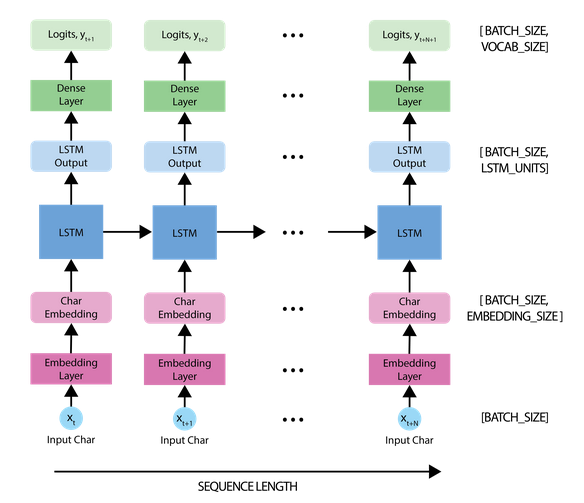


**Define the RNN model**

Now, we will define a function that we will use to actually build the model.


In [17]:
len(vocab)

83

In [18]:
def LSTM(rnn_units):
  return tf.keras.layers.LSTM(
    rnn_units,
    return_sequences=True,
    recurrent_initializer='glorot_uniform',
    recurrent_activation='sigmoid',
    stateful=True,
  )

In [19]:
### Defining the RNN Model ###
import tensorflow as tf
'''TODO: Add LSTM and Dense layers to define the RNN model using the Sequential API.'''
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.Sequential([
    # Layer 1: Embedding layer to transform indices into dense vectors
    #   of a fixed embedding size
    tf.keras.layers.Input(batch_shape=(batch_size, None)),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    # Layer 2: LSTM with `rnn_units` number of units.
    # TODO: Call the LSTM function defined above to add this layer.
    LSTM(rnn_units),
    # LSTM('''TODO'''),

    # Layer 3: Dense (fully-connected) layer that transforms the LSTM output
    #   into the vocabulary size.
    # TODO: Add the Dense layer.
    tf.keras.layers.Dense(vocab_size)
    # '''TODO: DENSE LAYER HERE'''
  ])

  return model

# Build a simple model with default hyperparameters. You will get the
#   chance to change these later.
rnn_model = build_model(len(vocab), embedding_dim=256, rnn_units=1024, batch_size=32)


**Test out the RNN model**

It's always a good idea to run a few simple checks on our model to see that it behaves as expected.

First, we can use the `Model.summary` function to print out a summary of our model's internal workings. Here we can check the layers in the model, the shape of the output of each of the layers, the batch size, etc.


In [20]:
83*256

21248

In [21]:
4*1024*256 # Wx

1048576

In [22]:
4*1024*1024

4194304

In [23]:
4194304+1048576

5242880

In [24]:
4* 1024 + 5242880

5246976

In [25]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (32, None, 256)             │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (32, None, 1024)            │       5,246,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, None, 83)              │          85,075 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,353,299 (20.42 MB)

 Trainable params: 5,353,299 (20.42 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
(1024*(1024+256)+1024)*4


5246976



We can also quickly check the dimensionality of our output, using a sequence length of 100. Note that the model can be run on inputs of any length.


In [27]:

x, y = get_batch(vectorized_songs, seq_length=100, batch_size=32)
pred = rnn_model(x)
print("Input shape:      ", x.shape, " # (batch_size, sequence_length)")
print("Prediction shape: ", pred.shape, "# (batch_size, sequence_length, vocab_size)")

Input shape:       (32, 100)  # (batch_size, sequence_length)
Prediction shape:  (32, 100, 83) # (batch_size, sequence_length, vocab_size)



**Predictions from the untrained model**

Let's take a look at what our untrained model is predicting.

To get actual predictions from the model, we sample from the output distribution, which is defined by a `softmax` over our character vocabulary. This will give us actual character indices. This means we are using a [categorical distribution](https://en.wikipedia.org/wiki/Categorical_distribution) to sample over the example prediction. This gives a prediction of the next character (specifically its index) at each timestep.

Note here that we sample from this probability distribution, as opposed to simply taking the `argmax`, which can cause the model to get stuck in a loop.

Let's try this sampling out for the first example in the batch.


In [28]:
pred[0]

<tf.Tensor: shape=(100, 83), dtype=float32, numpy=
array([[-3.9606406e-03, -3.0853632e-03, -1.1788819e-03, ...,
        -7.9975184e-03,  8.6960569e-04, -3.3135535e-03],
       [ 5.6926679e-04, -5.8488064e-03, -3.3018088e-03, ...,
        -5.0361431e-03,  9.5491554e-04, -1.9138283e-03],
       [ 1.0073893e-02,  1.5984124e-03, -4.4012889e-03, ...,
        -6.3064210e-03, -9.2881045e-04, -7.1592024e-03],
       ...,
       [ 2.7757622e-03, -7.5496435e-03,  1.2381793e-02, ...,
         5.1937066e-05, -3.9742989e-03,  6.1038940e-04],
       [ 2.7675964e-03, -6.2702075e-03,  1.0372909e-02, ...,
         1.4560716e-04, -8.2267337e-03, -2.7784347e-03],
       [-2.3129266e-03, -1.0284981e-02,  9.5962770e-03, ...,
        -3.0242885e-03, -7.8852475e-03, -6.3238163e-03]], dtype=float32)>

In [29]:


sampled_indices = tf.random.categorical(pred[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices,axis=-1).numpy()
sampled_indices



array([82, 78, 27,  2, 43, 24, 67, 44, 25, 46, 67, 48, 66, 49, 74, 27, 22,
       40, 61,  6,  0, 46, 77, 50, 72, 50, 54, 56, 45, 66, 40, 59, 63, 11,
       30, 53, 29, 30, 15,  8, 78, 64, 57, 42, 42, 33, 10, 13, 74, 57, 78,
        3, 41, 48, 24,  9, 45, 59, 20, 78, 56,  4, 10,  8,  7, 51,  3, 46,
       35, 62, 69, 44, 47, 59, 41, 54, 60, 36, 27, 78, 67, 82, 57, 44, 24,
       58, 69, 40, 39, 66, 77, 60, 29,  9, 15, 67, 79, 79, 78, 20])



We can now decode these to see the text predicted by the untrained model:


In [30]:
print("Input: \n", repr("".join(idx2char[x[0]])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices])))

Input: 
 "|!\n\nX:69\nT:Dinky's\nZ: id:dc-reel-62\nM:C\nL:1/8\nK:A Mixolydian\nfed|ceBe ABcd|egfd ecAa|gBB2 gBaB|gBB2 "

Next Char Predictions: 
 '|wB!R=lS>UlWkXsB:Of(\nUvYqY^aTkOdh/E]DE3,wibQQH.1sbw"PW=-Td8wa#.,)Z"UJgnSVdP^eKBwl|bS=cnONkveD-3lxxw8'




As you can see, the text predicted by the untrained model is pretty nonsensical! How can we do better? We can train the network!


## Training the model: loss and training operations

Now it's time to train the model!

At this point, we can think of our next character prediction problem as a standard classification problem. Given the previous state of the RNN, as well as the input at a given time step, we want to predict the class of the next character -- that is, to actually predict the next character.

To train our model on this classification task, we can use a form of the `crossentropy loss` (negative log likelihood loss). Specifically, we will use the `sparse_categorical_crossentropy` loss, as it utilizes integer targets for categorical classification tasks. We will want to compute the loss using the true targets -- the `labels` -- and the predicted targets -- the `logits`.

Let's first compute the loss using our example predictions from the untrained model:

In [31]:
### Defining the loss function ###

'''TODO: define the loss function to compute and return the loss between
    the true labels and predictions (logits). Set the argument from_logits=True.'''
def compute_loss(labels, logits):
  loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
  # loss = tf.keras.losses.sparse_categorical_crossentropy('''TODO''', '''TODO''', from_logits=True) # TODO
  return loss

'''TODO: compute the loss using the true next characters from the example batch
    and the predictions from the untrained model several cells above'''
example_batch_loss = compute_loss(y, pred)
# example_batch_loss = compute_loss('''TODO''', '''TODO''') # TODO

print("Prediction shape: ", pred.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (32, 100, 83)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       4.4192824


Let's start by defining some hyperparameters for training the model. To start, we have provided some reasonable values for some of the parameters. It is up to you to use what we've learned in class to help optimize the parameter selection here!

In [53]:
### Hyperparameter setting and optimization ###

# Optimization parameters:
num_training_iterations = 50  # Increase this to train longer
batch_size = 32  # Experiment between 1 and 64
seq_length = 100  # Experiment between 50 and 500
learning_rate = 5e-3  # Experiment between 1e-5 and 1e-1

# Model parameters:
vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 100  # Experiment between 1 and 2048

import os

checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)  # Crée le dossier s'il n'existe pas
checkpoint_prefix = os.path.join(checkpoint_dir, "my_ckpt.weights.h5")



Now, we are ready to define our training operation -- the optimizer and duration of training -- and use this function to train the model. You will experiment with the choice of optimizer and the duration for which you train your models, and see how these changes affect the network's output. Some optimizers you may like to try are `Adam` and `Adagrad`.

First, we will instantiate a new model and an optimizer. Then, we will use the `tf.GradientTape` method to perform the backpropagation operations.

We will also generate a print-out of the model's progress through training, which will help us easily visualize whether or not we are minimizing the loss.


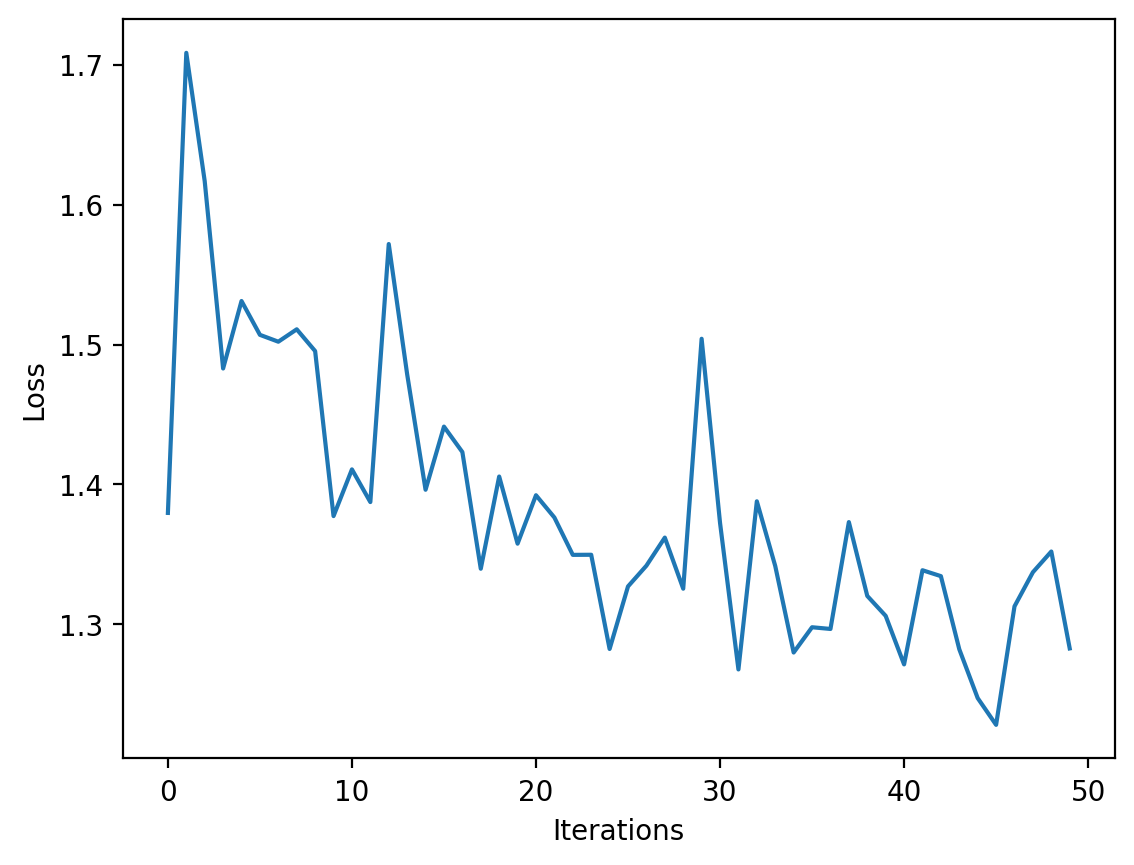

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [01:57<00:00,  2.35s/it]


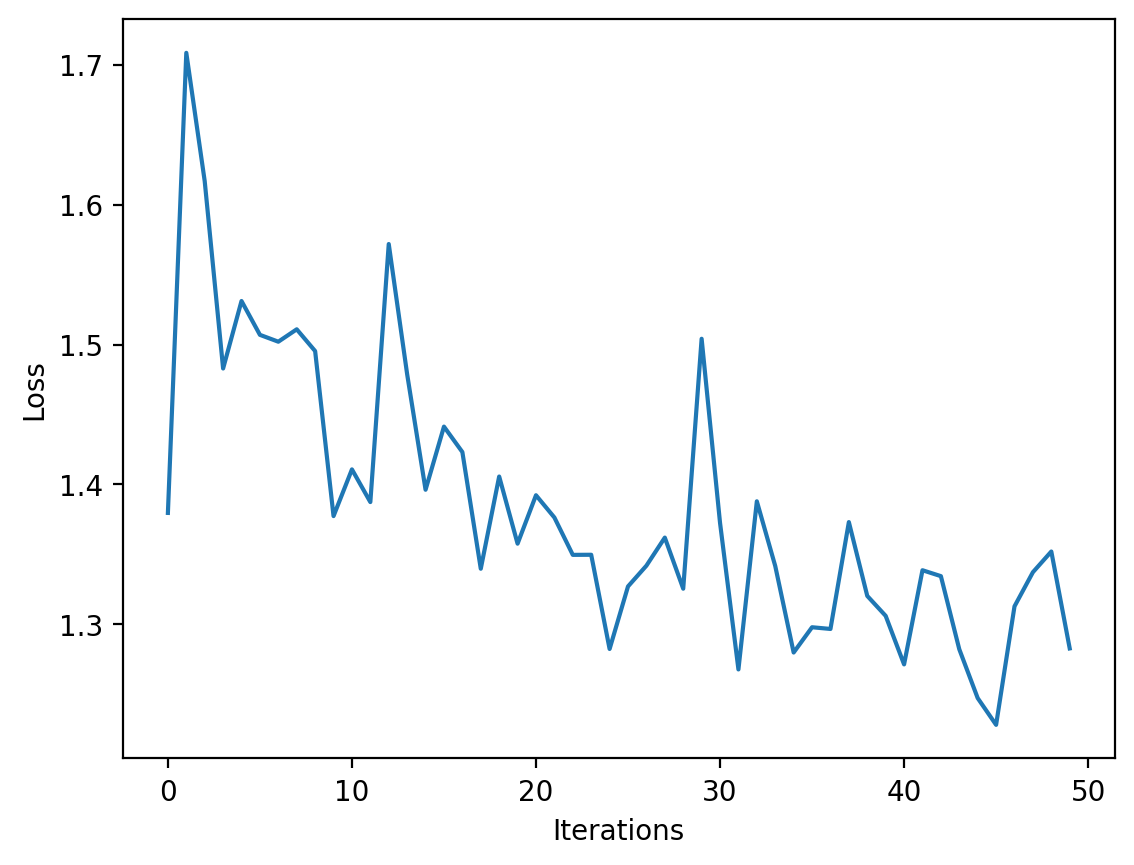

In [54]:
### Define optimizer and training operation ###
from tqdm import tqdm
'''TODO: instantiate a new model for training using the `build_model`
  function and the hyperparameters created above.'''
#model = build_model(vocab_size, embedding_dim, rnn_units, batch_size)
# model = build_model('''TODO: arguments''')

'''TODO: instantiate an optimizer with its learning rate.
  Checkout the tensorflow website for a list of supported optimizers.
  https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/
  Try using the Adam optimizer to start.'''
optimizer = tf.keras.optimizers.Adam(learning_rate)
# optimizer = # TODO

@tf.function
def train_step(x, y):
  # Use tf.GradientTape()
  with tf.GradientTape() as tape:

    '''TODO: feed the current input into the model and generate predictions'''
    y_hat = rnn_model(x) # TODO
    # y_hat = model('''TODO''')

    '''TODO: compute the loss!'''
    loss = compute_loss(y, y_hat) # TODO
    # loss = compute_loss('''TODO''', '''TODO''')

  # Now, compute the gradients
  '''TODO: complete the function call for gradient computation.
      Remember that we want the gradient of the loss with respect all
      of the model parameters.
      HINT: use `model.trainable_variables` to get a list of all model
      parameters.'''
  grads = tape.gradient(loss, rnn_model.trainable_variables) # TODO
  # grads = tape.gradient('''TODO''', '''TODO''')

  # Apply the gradients to the optimizer so it can update the model accordingly
  optimizer.apply_gradients(zip(grads, rnn_model.trainable_variables))
  return loss

##################
# Begin training!#
##################

history = []
plotter = util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss')
if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

for iter in tqdm(range(num_training_iterations)):

  # Grab a batch and propagate it through the network
  x_batch, y_batch = get_batch(vectorized_songs, seq_length, batch_size)
  loss = train_step(x_batch, y_batch)

  # Update the progress bar
  history.append(loss.numpy().mean())
  plotter.plot(history)

  # Update the model with the changed weights!
  if iter % 100 == 0:
    rnn_model.save_weights(checkpoint_prefix)
# Save the trained model and the weights
rnn_model.save_weights(checkpoint_prefix)


## Generate music using the RNN model

Now, we can use our trained RNN model to generate some music! When generating music, we'll have to feed the model some sort of seed to get it started (because it can't predict anything without something to start with!).

Once we have a generated seed, we can then iteratively predict each successive character (remember, we are using the ABC representation for our music) using our trained RNN. More specifically, recall that our RNN outputs a `softmax` over possible successive characters. For inference, we iteratively sample from these distributions, and then use our samples to encode a generated song in the ABC format.

Then, all we have to do is write it to a file and listen!

**Restore the latest checkpoint**

To keep this inference step simple, we will use a batch size of 1. Because of how the RNN state is passed from timestep to timestep, the model will only be able to accept a fixed batch size once it is built.

To run the model with a different `batch_size`, we'll need to rebuild the model and restore the weights from the latest checkpoint, i.e., the weights after the last checkpoint during training:


In [55]:
# Rebuild the model using a batch_size of 1
model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)
# model = build_model('''TODO''', '''TODO''', '''TODO''', batch_size=1)

# Récupère le dernier checkpoint dans le dossier checkpoint_dir
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)
if latest_checkpoint:
    print("Loading weights from:", latest_checkpoint)
    model.load_weights(latest_checkpoint)
else:
    print("No checkpoint found in", checkpoint_dir)

# Construire le modèle en précisant la forme d'entrée
model.build(tf.TensorShape([1, None]))

# Afficher le résumé du modèle
model.summary()


No checkpoint found in ./training_checkpoints


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (1, None, 256)              │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (1, None, 100)              │         142,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (1, None, 83)               │           8,383 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 172,431 (673.56 KB)

 Trainable params: 172,431 (673.56 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
4*(100*(256+100)+100)

142800

In [57]:
rnn_units


100



Notice that we have fed in a fixed batch_size of 1 for inference.


**The prediction procedure**

Now, we're ready to write the code to generate text in the ABC music format:

*  Initialize a "seed" start string and the RNN state, and set the number of characters we want to generate.

*  Use the start string and the RNN state to obtain the probability distribution over the next predicted character.

*  Sample from multinomial distribution to calculate the index of the predicted character. This predicted character is then used as the next input to the model.

*  At each time step, the updated RNN state is fed back into the model, so that it now has more context in making the next prediction. After predicting the next character, the updated RNN states are again fed back into the model, which is how it learns sequence dependencies in the data, as it gets more information from the previous predictions.


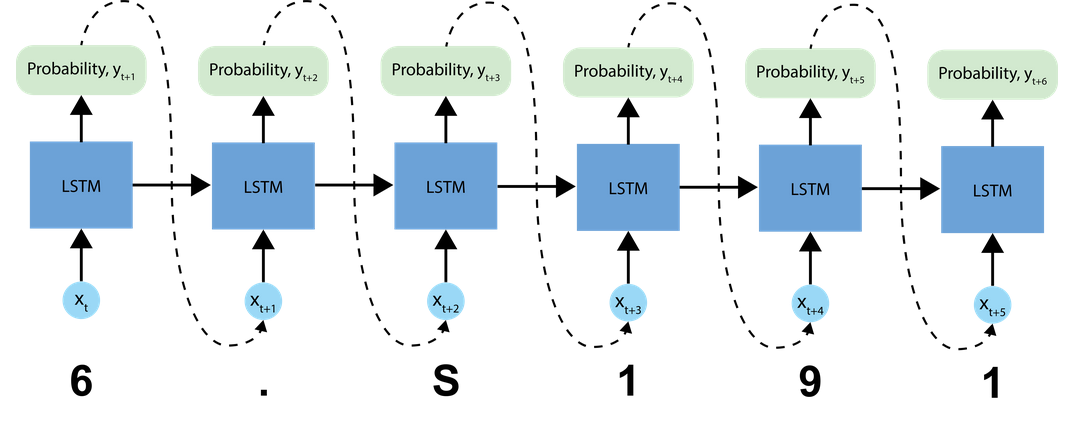

Complete and experiment with this code block (as well as some of the aspects of network definition and training!), and see how the model performs. How do songs generated after training with a small number of epochs compare to those generated after a longer duration of training?

In [58]:
def reset_model_states(model):
    # Parcourt toutes les couches du modèle et réinitialise l'état
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()


In [59]:


### Prediction of a generated song ###

def generate_text(model, start_string, generation_length=1000):
  # Evaluation step (generating ABC text using the learned RNN model)

  '''TODO: convert the start string to numbers (vectorize)'''
  input_eval = [char2idx[s] for s in start_string] # TODO
  # input_eval = ['''TODO''']
  input_eval = tf.expand_dims(input_eval, 0)

  # Empty string to store our results
  text_generated = []

  # Here batch size == 1
  reset_model_states(model)
  tqdm._instances.clear()

  for i in tqdm(range(generation_length)):
      '''TODO: evaluate the inputs and generate the next character predictions'''
      predictions = model(input_eval)
      # predictions = model('''TODO''')

      # Remove the batch dimension
      predictions = predictions[0]

      '''TODO: use a multinomial distribution to sample'''
      predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()
      # predicted_id = tf.random.categorical('''TODO''', num_samples=1)[-1,0].numpy()

      # Pass the prediction along with the previous hidden state
      #   as the next inputs to the model
      input_eval = tf.expand_dims([predicted_id], 0)

      '''TODO: add the predicted character to the generated text!'''
      # Hint: consider what format the prediction is in vs. the output
      text_generated.append(idx2char[predicted_id]) # TODO
      # text_generated.append('''TODO''')

  return (start_string + ''.join(text_generated))







**Play back the generated music!**

We can now call a function to convert the ABC format text to an audio file, and then play that back to check out our generated music! Try training longer if the resulting song is not long enough, or re-generating the song!


In [60]:

'''TODO: Use the model and the function defined above to generate ABC format text of length 1000!
    As you may notice, ABC files start with "X" - this may be a good start string.'''
generated_text = generate_text(rnn_model, start_string="X", generation_length=1000) # TODO
# generated_text = generate_text('''TODO''', start_string="X", generation_length=1000)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:52<00:00, 19.03it/s]


In [61]:
generated_text

"X_MU_E|FEE EFF|A2G FEE:|!\nA,B,|B,EDE G2cA|BAcd cAEc|d2afa b3e|!\naAfd gdB|A2BG BGG2|ABAG FGAB|cece d^cde|!\ndefa d2A|BAgf e2fA|ABB2 AGG2|!\nd>BG AGE2|AGEG AGAF|D2FA D2GA|cAAF GEEF|!\nAdde fdcB|GBGA BcdA|BGAB A2BG|A2FE D2:|!\n\nX:8\nT:Mumolan's Gatt\nZ: id:dc-reel-179\nM:C\nL:1/8\nK:D Mixolydian\nFd|c2AB AGED|EDDF Dorian\nF|GEG, DAG|A,DEF G3:|!\n\n\nX:169\nT:Knanhny Mag Sthoupin\nZ: id:dc-jig-20\nM:6/8\nL:1/8\nK:A Dorian\nE|D2GB d2G2|EGAB G2Bd|edcB cAGE|DFAG FDEF|DFGA BGF2|!\nBcde fdaa|baag afge|dBB2 G2AG|]!\nGED2|=Acd BAFG|AdBG EGFA|BA2B EAFE|GFBG FD|]!\n\nX:103\nT:Jallort\nZ: id:dc-jig-47\nM:6/8\nL:1/|Bcg BcA|d2A B3|B2g ad:|!\n\nX:168\nT:Futous\nZ: id:dc-jig-34\nM:6/8\nL:1/8\nK:E Mixolydian\nA|e2c efg|edB g>e|fdd geB|dBA Bdg|!\ng3 gag|fdd e2:|!\nb|afd d3|D2F G2G|F2G DFG|BAF E2F|DED FEG|FGD A,A,D|]!\n\nX:3\nT:Bupsley's\nZ: id:dc-jig-44\nM:6/8\nL:1/8\nK:D Major\nDE|G2A BAA>|BdB2 ABAF|ABAG dGBd|!\nB2ce dBAF|GEBE BAFA|!\nG3EG Bdeg|abgb aged|BAAc dgfg|!\ndefd eAA2|GAEF GABd|f2af gabe|BdB

In [63]:
### Play back generated songs ###

generated_songs = util.extract_song_snippet(generated_text)

for i, song in enumerate(generated_songs):
  # Synthesize the waveform from a song
  waveform = util.play_song(song)

  # If its a valid song (correct syntax), lets play it!
  if waveform:
    print("Generated song", i)
    ipythondisplay.display(waveform)

Found 6 songs in text
Error converting ABC to MIDI: no active default note length provided for note processing. tPrev: None, token: <music21.abcFormat.ABCNote 'X'>, tNext: <music21.abcFormat.ABCNote '_MU'>
Generated song 1


Error converting ABC to MIDI: the object (<music21.meter.TimeSignature 6/8>, id()=2177625156256 is already found in this Stream (<music21.stream.Part 0x1fb04ac75b0>, id()=2177626830256)
Error converting ABC to MIDI: the object (<music21.meter.TimeSignature 6/8>, id()=2176379189376 is already found in this Stream (<music21.stream.Part 0x1faba4ee8f0>, id()=2176379185392)
Error converting ABC to MIDI: invalid literal for int() with base 10: '|Bcg BcA|d2A B3|B2g ad:|!'
Generated song 5


# YAHOO

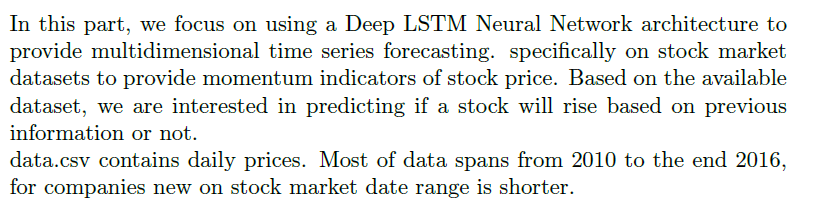

## Exe. 1

Upload the price data set, data.csv using pandas. Check the uploaded
dataset and its di
erent columns.

In [64]:
import pandas as pd
#from google.colab import drive
#drive.mount('/content/gdrive')
#prices_dataset = pd.read_csv('gdrive/My Drive/Colab Notebooks/data.csv', sep=',',header=0)
prices_dataset =  pd.read_csv('data.csv', header=0)


In [65]:
from IPython.display import display


display(prices_dataset)

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
...,...,...,...,...,...,...,...
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0
851261,2016-12-30,ZTS,53.639999,53.529999,53.270000,53.740002,1701200.0
851262,2016-12-30 00:00:00,AIV,44.730000,45.450001,44.410000,45.590000,1380900.0


## Exe. 2



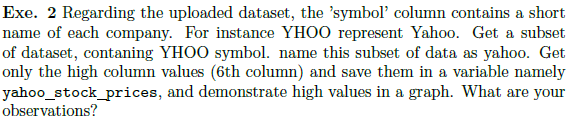

In [66]:
yahoo = prices_dataset[prices_dataset['symbol']=='YHOO']
yahoo

,date,symbol,open,close,low,high,volume
713,2010-01-04,YHOO,16.940001,17.100000,16.879999,17.200001,16587400.0
1181,2010-01-05,YHOO,17.219999,17.230000,17.000000,17.230000,11718100.0
1649,2010-01-06,YHOO,17.170000,17.170000,17.070000,17.299999,16422000.0
2117,2010-01-07,YHOO,16.809999,16.700001,16.570000,16.900000,31816300.0
2585,2010-01-08,YHOO,16.680000,16.700001,16.620001,16.760000,15470000.0
...,...,...,...,...,...,...,...
849257,2016-12-23,YHOO,38.459999,38.660000,38.369999,38.810001,3840100.0
849757,2016-12-27,YHOO,38.590000,38.919998,38.500000,39.070000,4240300.0
850257,2016-12-28,YHOO,39.119999,38.730000,38.709999,39.220001,4393500.0
850757,2016-12-29,YHOO,38.759998,38.639999,38.480000,38.930000,4170200.0


In [67]:
yahoo_stock_prices = yahoo.values[:,-2].astype('float32')
yahoo_stock_prices.shape

(1762,)

In [68]:
yahoo_stock_prices[1:10]

array([17.23, 17.3 , 16.9 , 16.76, 16.83, 16.86, 16.98, 17.23, 17.25],
      dtype=float32)

In [69]:
yahoo_stock_prices = yahoo_stock_prices.reshape(yahoo_stock_prices.shape[0], 1)

In [70]:
yahoo_stock_prices[1:10,:]

array([[17.23],
       [17.3 ],
       [16.9 ],
       [16.76],
       [16.83],
       [16.86],
       [16.98],
       [17.23],
       [17.25]], dtype=float32)

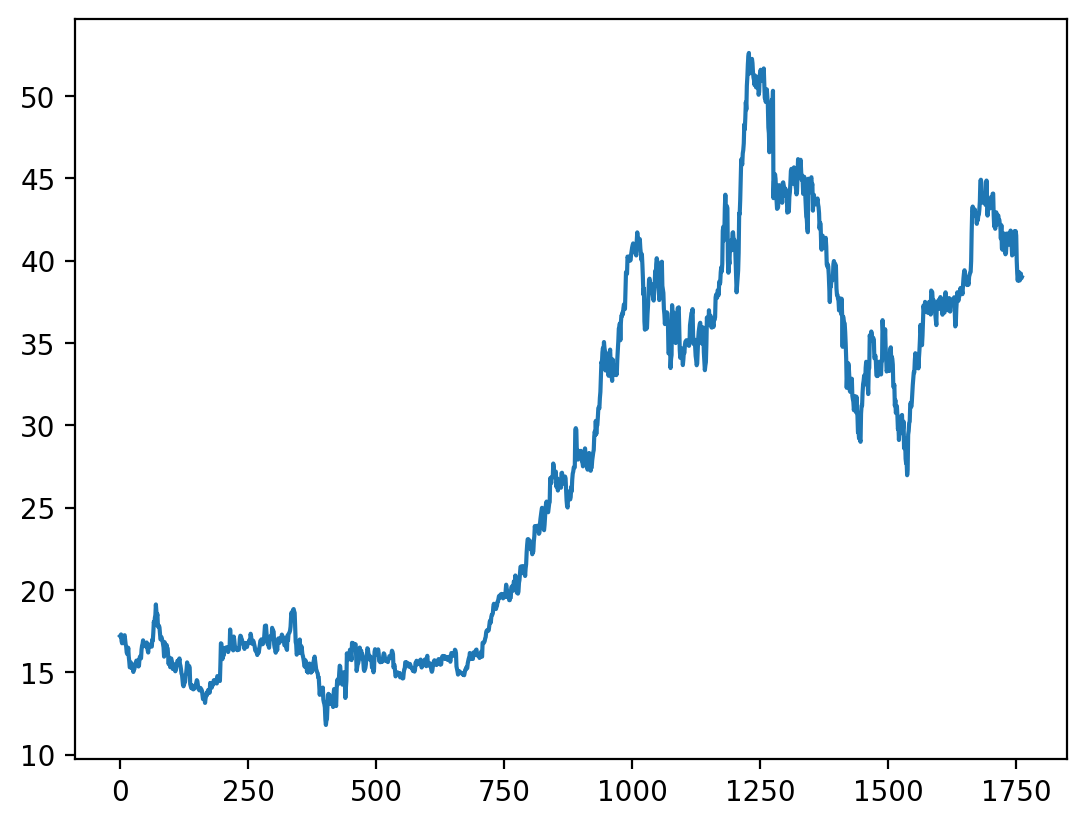

In [71]:
import matplotlib.pyplot as plt

plt.plot(yahoo_stock_prices)
plt.show()

Observation: Over the course of six years, Yahoo’s stock tripled.

##  Exe. 3



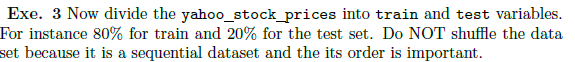

In [72]:
train_size = int(len(yahoo_stock_prices) * 0.80)
test_size = len(yahoo_stock_prices) - train_size
train= yahoo_stock_prices[0:train_size,:]
test  = yahoo_stock_prices[train_size:len(yahoo_stock_prices),:]
print(len(train), len(test))

1409 353


In [73]:
train.shape

(1409, 1)

##  Exe. 4



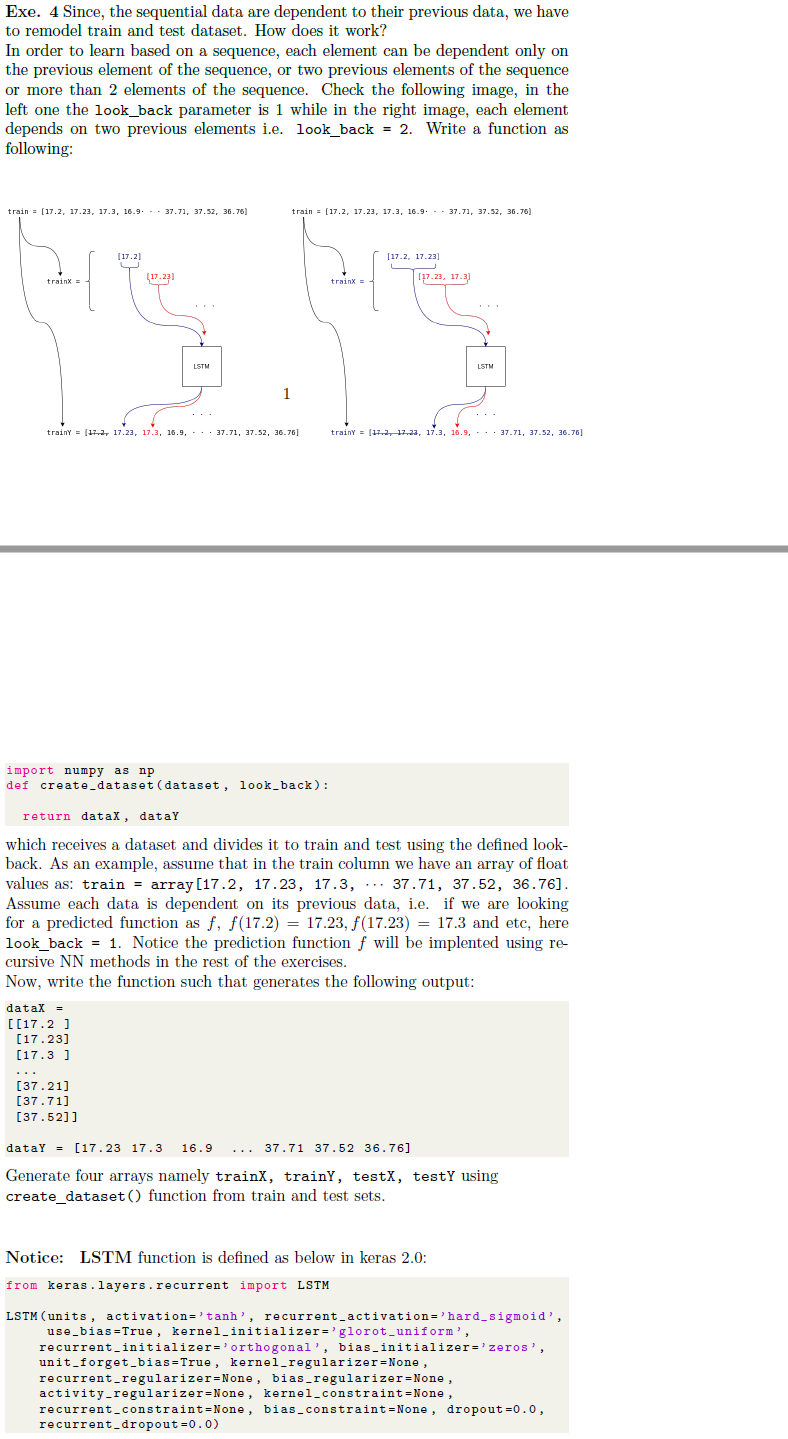

In [74]:
train

array([[17.2 ],
       [17.23],
       [17.3 ],
       ...,
       [37.71],
       [37.52],
       [36.76]], dtype=float32)

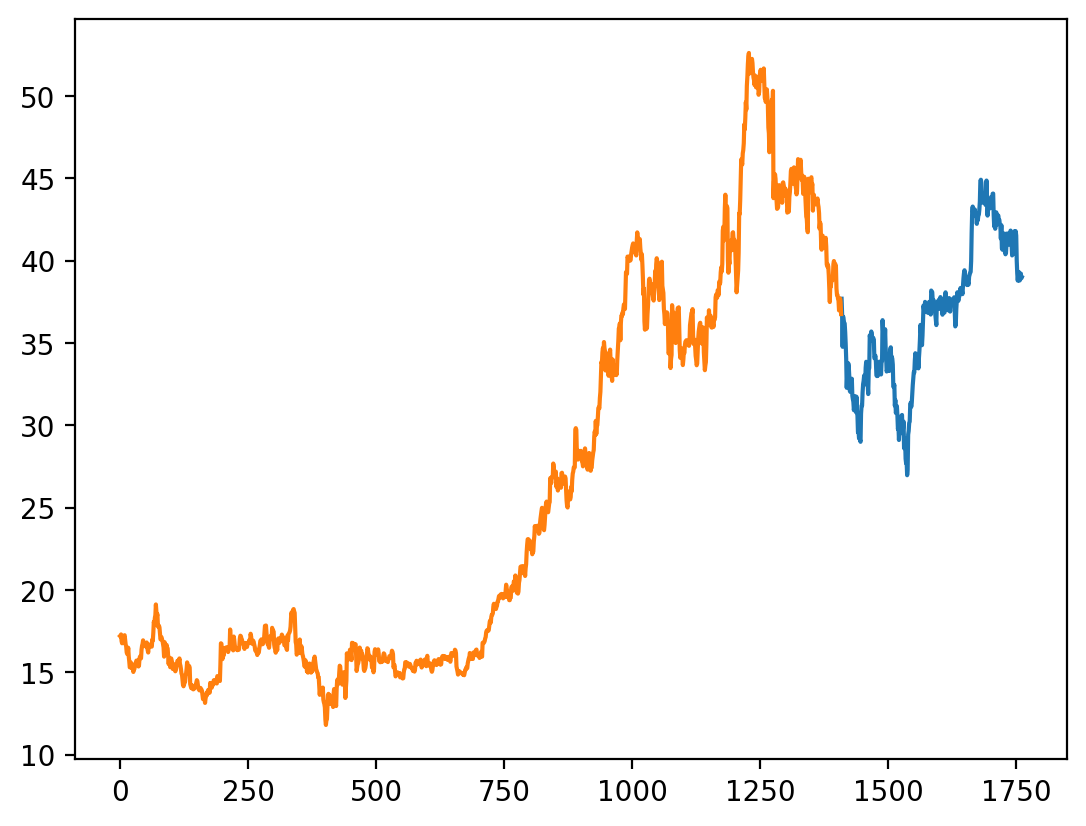

In [75]:
plt.plot(range(train_size,len(yahoo_stock_prices)),test)
plt.plot(range(0,train_size),train)

In [76]:
import numpy as np
def create_dataset(dataset, look_back=2):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	dataX = np.array(dataX)
	dataY = np.array(dataY)
	return dataX, dataY

In [77]:
# reshape into X=t and Y=t+1
look_back = 5
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [78]:
print(trainX.shape)
#print(trainX)
print(trainY.shape)
#print(trainY)
print(testX.shape)
print(testY.shape)

(1404, 5)
(1404,)
(348, 5)
(348,)


In [79]:
train

array([[17.2 ],
       [17.23],
       [17.3 ],
       ...,
       [37.71],
       [37.52],
       [36.76]], dtype=float32)

In [80]:
trainX

array([[17.2 , 17.23, 17.3 , 16.9 , 16.76],
       [17.23, 17.3 , 16.9 , 16.76, 16.83],
       [17.3 , 16.9 , 16.76, 16.83, 16.86],
       ...,
       [37.92, 37.69, 37.57, 36.98, 37.21],
       [37.69, 37.57, 36.98, 37.21, 37.71],
       [37.57, 36.98, 37.21, 37.71, 37.52]], dtype=float32)

In [81]:
trainY

array([16.83, 16.86, 16.98, ..., 37.71, 37.52, 36.76], dtype=float32)

In [82]:
trainX.shape

(1404, 5)

In [83]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1],1 ))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1],1))

In [84]:
#print(trainX)
print(trainX.shape)
print(trainY.shape)

(1404, 5, 1)
(1404,)


In [85]:
trainX[0]


array([[17.2 ],
       [17.23],
       [17.3 ],
       [16.9 ],
       [16.76]], dtype=float32)

In [86]:
trainY[0]

np.float32(16.83)

##  Exe. 5

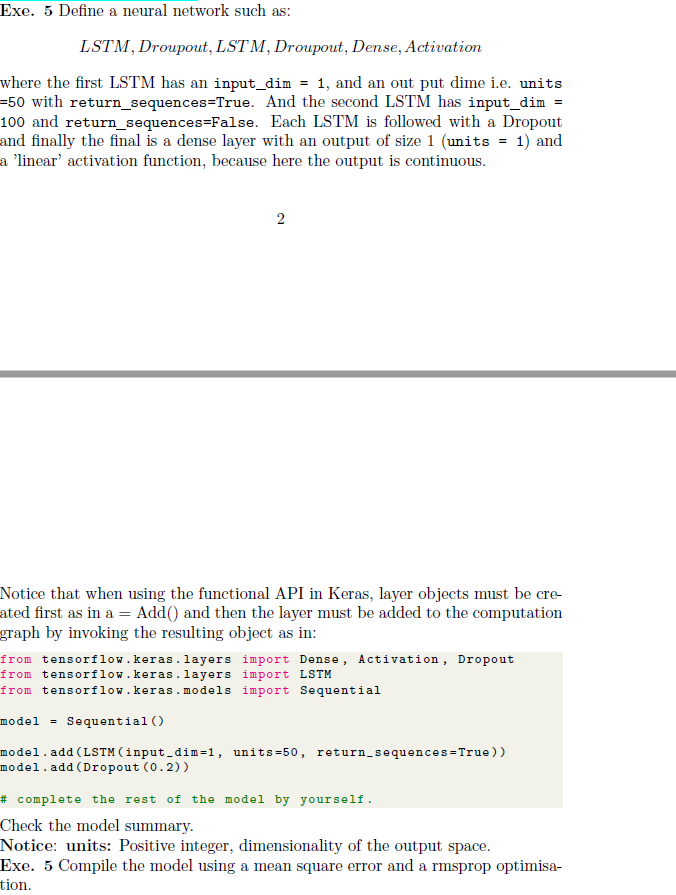

In [87]:
#from subprocess import check_output
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.models import Sequential
#from sklearn.cross_validation import  train_test_split
import time

model = Sequential()

model.add(LSTM(input_shape=(look_back,1), units=100, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1, activation ='linear'))
model.summary()

#The number of parameters of LSTM, taking input vectors of size m and giving output vectors of size n is:
#4(nm+n^2+n)

C:\Users\lulul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 5, 100)              │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 100)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
4*(100+1)*100+100

40500

In [89]:
model.compile(loss='mse', optimizer='nadam')

## Exe. 6

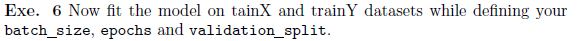

In [90]:
model.fit(
    trainX,
    trainY,
    batch_size=32,
    epochs=100,
    validation_split=0.2)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 334.3287 - val_loss: 1176.0195
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 170.1316 - val_loss: 1000.0365
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 134.4403 - val_loss: 897.8168
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 111.7620 - val_loss: 814.9494
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 94.3354 - val_loss: 745.7032
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 84.4852 - val_loss: 689.8394
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 77.8395 - val_loss: 649.2136
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 73.1366 - val_loss: 617.1121
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 72.0706 - val_loss: 590.3099
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 69.0072 - val_loss: 568.7825
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 66.9124 - val_loss: 553.9112
Epoch 12/100


## Exe. 7

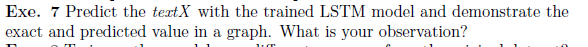

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


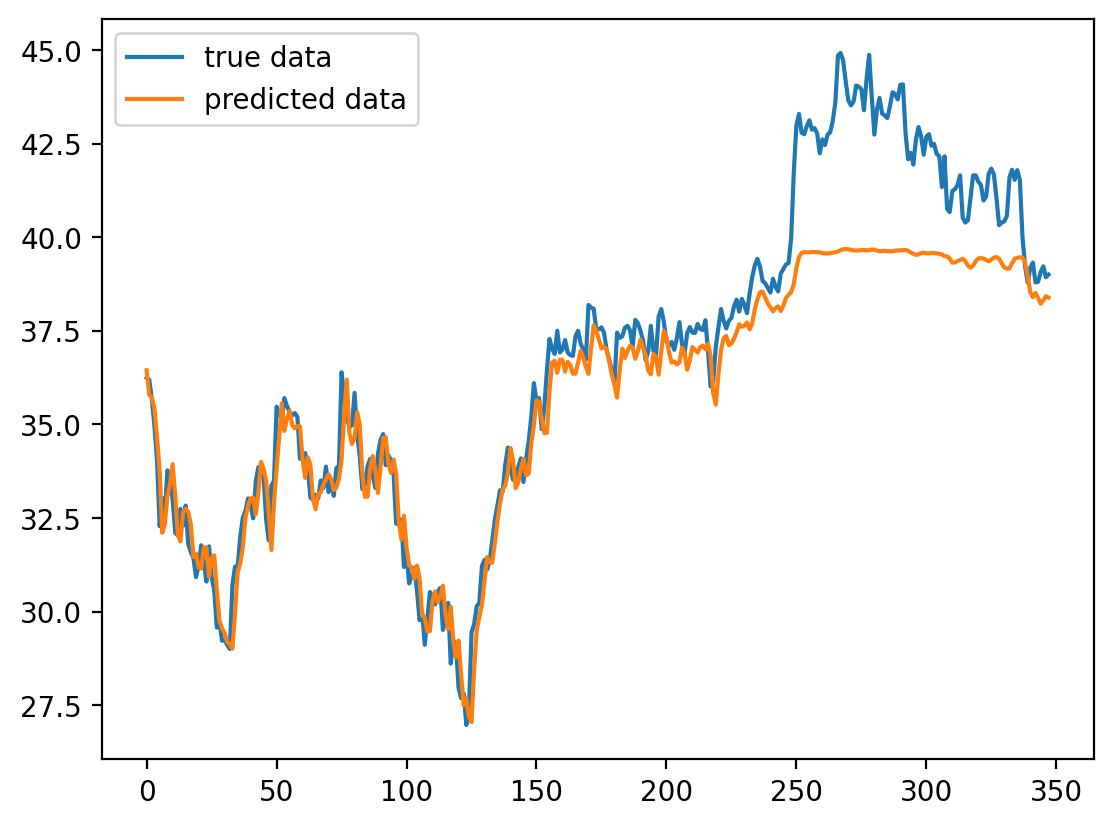

In [91]:
import matplotlib.pyplot as plt
predicted = model.predict(testX)
plt.plot(testY, label = 'true data')
plt.plot(predicted, label = 'predicted data')
plt.legend()
plt.show()


The real one and the predicted one are very close. We can see a difference in the last 100 observations where the real go up and the predicted stay the same.